# Option B Exploration

This notebook contains the exploration component for Option B, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful staring points for the extension include:_
* **Edge/lane detection using your own images:** Apply edge detection to your own photos. Where does it go wrong? Why might that be the case? Are there other edge detection algorithms that work better?
* **Enhancing the edge detection algorithm** Can you improve the edge detection algorithm somewhere?

For more detailed instructions, please see the [Project 1 Guidelines](https://docs.google.com/document/d/1_yLzSePaVH2OrQgzZsu-1sZ4ez1Da9_tFzZFM3LCarQ/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* Source 1: Wood, Kevin. OpenCV Python Hough Line Transform (Line Detection Algorithm Explained + Code). YouTube, 27 July 2023, https://www.youtube.com/watch?v=eNIrnHasZNI.
* Source 2: Nixon, Mark. “Improving an Extended Version of the Hough Transform.” Signal Processing, vol. 19, no. 4, 1990, pp. 321–335.
* Source 3: I. C. Baykal, "Improving the Hough Transform Through Three New Morphological Operators," 2019 International Artificial Intelligence and Data Processing Symposium (IDAP), Malatya, Turkey, 2019, pp. 1-6, doi: 10.1109/IDAP.2019.8875918.
* Source 4: “Comprehensive Guide to Edge Detection Algorithms.” GeeksforGeeks, https://www.geeksforgeeks.org/computer-vision/comprehensive-guide-to-edge-detection-algorithms/.
* Source 5: Singh, Aditya. Lane Detection Sliding Windows. GitHub, https://github.com/Aditya-Singh-SSJ2/Lane_Detection_Sliding_Windows.

The video in Source 1 explains the Hough line transform algorithm and implements it using the OpenCV open-source library in Python. It demonstrates the effect of changing thresholding, using/not using blurring, etc.

Source 2 Paper proposes an improved version of the Hough transform that reduces its computational cost and memory usage while maintaining robustness to noise. It introduces an extended method that refines shape parameters using residual gradient information and nonlinear least squares, combined with a coarse-to-fine Hough transform pipeline. The results show that this hybrid approach achieves similar accuracy to the traditional Hough transform while significantly improving efficiency.

Source 3 Paper improves the Hough transform by introducing three lightweight morphological operators—thinning, stretching, and smoothing—that preprocess binary edge images to make line structures longer and cleaner. The key idea is that the Hough transform performs better on long, continuous lines, so stretching edges increases detection reliability while smoothing reduces artifacts introduced during expansion. Experimental results show significant improvements in both line and circle detection accuracy with minimal computational overhead, making the method suitable for real-time applications.  

Source 4 website provides an overview of common edge detection algorithms used in computer vision, including Sobel, Prewitt, Laplacian, and Canny methods. It explains how these techniques identify intensity changes in images to extract meaningful boundaries, highlighting trade-offs between noise sensitivity and edge localization. The page offers mathematical explanations behind each method.

Source 5 is a github repository that implements a lane detection pipeline using a sliding window approach, where lane pixels are identified and tracked across image regions to fit lane boundaries. Unlike Hough-based methods, it relies on histogram-based initialization and iterative window updates to follow lane lines, making it more suitable for curved lanes.

## Code (70 points)
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient.

You not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


In [3]:
!git clone https://github.com/miaxiaozl/CS131.git
%cd CS131/spring_2026/project1_release/option_B

Cloning into 'CS131'...
remote: Enumerating objects: 2786, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 2786 (delta 15), reused 0 (delta 0), pack-reused 2757 (from 1)
Receiving objects: 100% (2786/2786), 212.35 MiB | 21.02 MiB/s, done.
Resolving deltas: 100% (855/855), done.
Updating files: 100% (140/140), done.
/content/CS131/spring_2026/project1_release/option_B


In [4]:
from skimage import io, color, transform
from edge import canny, hough_transform
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
import cv2

# Image Setup: ROI

In [5]:
def load_grayscale_image(path, resize_shape=(800, 600)):
    img = io.imread(path)

    # Drop alpha channel if RGBA
    if img.ndim == 3:
        img = img[:, :, :3]
        img_gray = color.rgb2gray(img)
    else:
        img_gray = img

    img_gray = transform.resize(img_gray, resize_shape, anti_aliasing=True)

    return img_gray

In [6]:
def polygon_mask(H, W, polygon):
    y, x = np.mgrid[:H, :W]
    points = np.vstack((x.ravel(), y.ravel())).T

    path = Path(polygon)
    mask = path.contains_points(points)

    return mask.reshape(H, W)

In [7]:
def get_roi_polygon(image_name, H, W):
    if image_name == "montmartre":
        return [
            (0, H),
            (W, H),
            (int(0.70 * W), int(0.58 * H)),
            (int(0.25 * W), int(0.58 * H)),
        ]

    elif image_name == "paris":
        return [
            (int(-0.05 * W), H),
            (int(1.05 * W), H),
            (int(1.00 * W), int(0.50 * H)),
            (int(0.60 * W), int(0.48 * H)),
            (int(0.00 * W), int(0.65 * H)),
        ]

    elif image_name == "kyoto":
        return [
            (int(0.00 * W), H),
            (int(1.00 * W), H),
            (int(0.95 * W), int(0.40 * H)),
            (int(0.20 * W), int(0.45 * H)),
        ]

    else:
        raise ValueError("image_name must be 'montmartre', 'paris', or 'kyoto'")

In [8]:
def extract_roi_edges(
    path,
    image_name,
    resize_shape=(800, 600),
    kernel_size=5,
    sigma=1.4,
    high=0.03,
    low=0.02,
    show=True
):
    # Load image
    img_gray = load_grayscale_image(path, resize_shape=resize_shape)

    # Run your Canny
    edges = canny(img_gray, kernel_size=kernel_size, sigma=sigma, high=high, low=low)

    H, W = edges.shape

    # ROI logic differs only here
    polygon = get_roi_polygon(image_name, H, W)
    mask = polygon_mask(H, W, polygon)

    roi = edges * mask

    if show:
        plt.figure(figsize=(14, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(img_gray, cmap="gray")
        plt.title("Input Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(mask, cmap="gray")
        plt.title("ROI Mask")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(roi, cmap="gray")
        plt.title("Edges in ROI")
        plt.axis("off")

        plt.show()

    return img_gray, edges, mask, roi

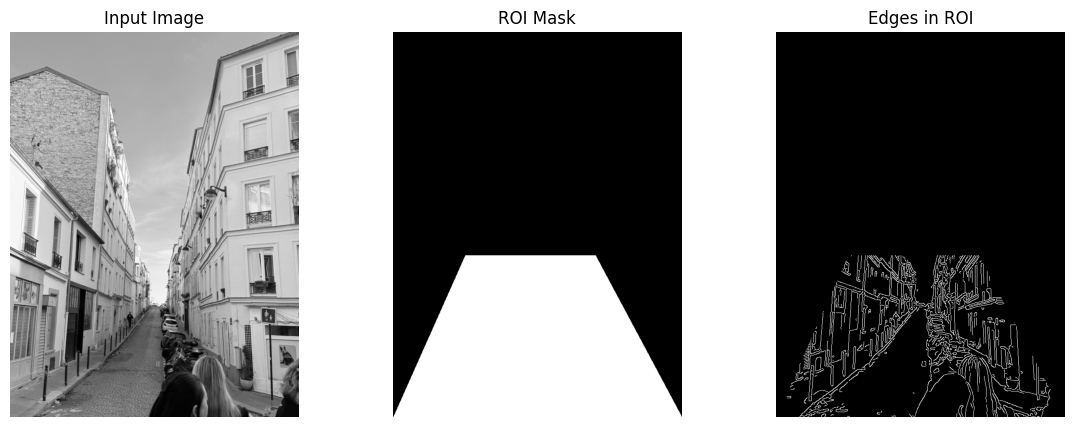

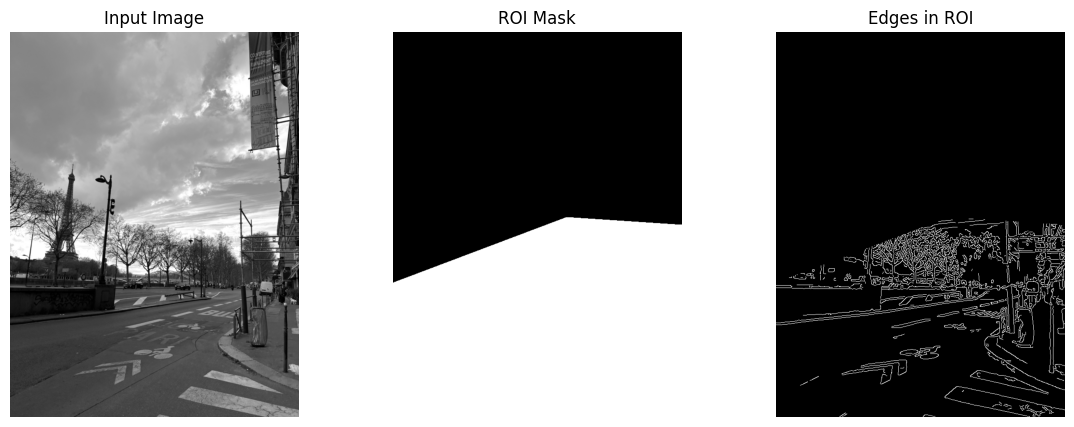

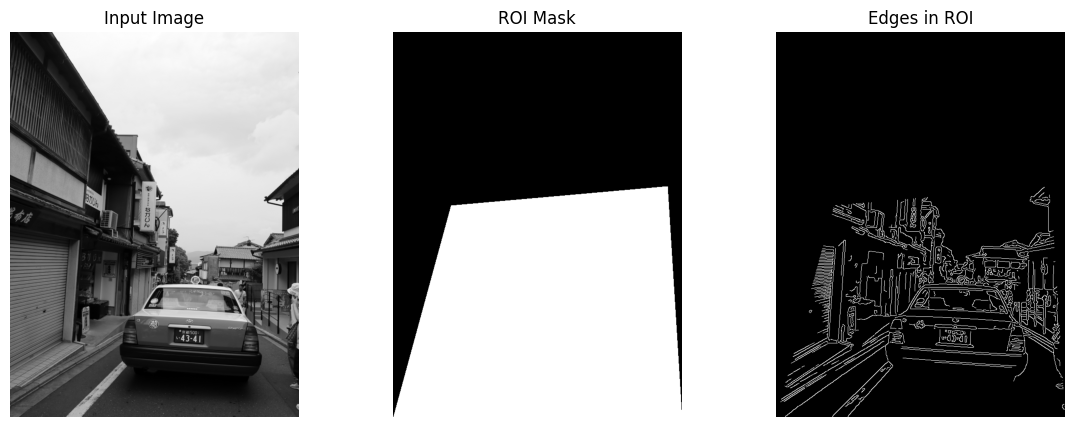

In [9]:
mont_img, mont_edges, mont_mask, mont_roi = extract_roi_edges(
    "montmartre.png",
    "montmartre"
)

paris_img, paris_edges, paris_mask, paris_roi = extract_roi_edges(
    "paris.png",
    "paris"
)

kyoto_img, kyoto_edges, kyoto_mask, kyoto_roi = extract_roi_edges(
    "kyoto.png",
    "kyoto"
)

# Hough Line Transform

In [20]:
def apply_hough_lines(img_gray, roi, num_peaks=20, min_y_frac=0.55, linewidth=4):
    acc, rhos, thetas = hough_transform(roi)

    xs_left, ys_left = [], []
    xs_right, ys_right = [], []

    acc_copy = acc.copy()
    H, W = img_gray.shape

    for _ in range(num_peaks):
        idx = np.argmax(acc_copy)
        r_idx = idx // acc_copy.shape[1]
        t_idx = idx % acc_copy.shape[1]
        acc_copy[r_idx, t_idx] = 0

        rho = rhos[r_idx]
        theta = thetas[t_idx]

        if abs(np.sin(theta)) < 1e-6:
            continue

        # Convert Hough line to y = ax + b
        a = -(np.cos(theta) / np.sin(theta))
        b = rho / np.sin(theta)

        # Skip nearly horizontal or nearly vertical lines
        if abs(a) < 0.2 or abs(a) > 8:
            continue

        if xs_left and xs_right:
            break

        if a < 0:
            if xs_left:
                continue
            xs, ys = xs_left, ys_left
        else:
            if xs_right:
                continue
            xs, ys = xs_right, ys_right

        for x in range(W):
            y = a * x + b
            if min_y_frac * H < y < H:
                xs.append(x)
                ys.append(int(round(y)))

    plt.figure(figsize=(8, 6))
    plt.imshow(img_gray, cmap="gray")
    plt.plot(xs_left, ys_left, linewidth=linewidth)
    plt.plot(xs_right, ys_right, linewidth=linewidth)
    plt.axis("off")
    plt.show()

    return acc, rhos, thetas, (xs_left, ys_left), (xs_right, ys_right)

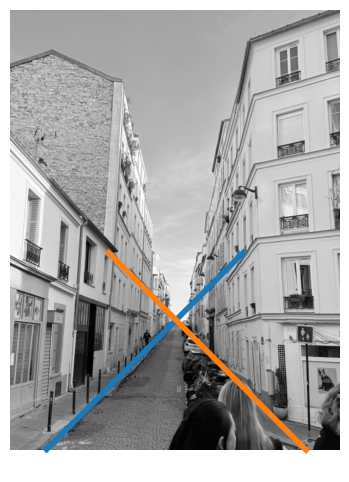

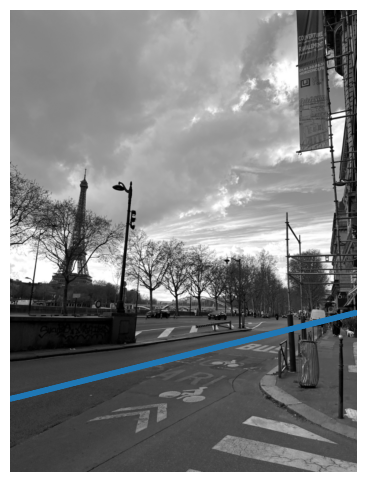

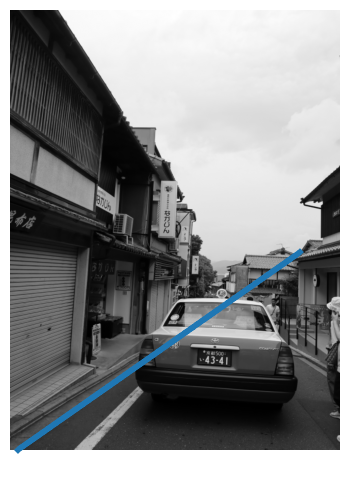

In [72]:
mont_acc, mont_rhos, mont_thetas, mont_left, mont_right = apply_hough_lines(
    mont_img, mont_roi
)

paris_acc, paris_rhos, paris_thetas, paris_left, paris_right = apply_hough_lines(
    paris_img, paris_roi
)

kyoto_acc, kyoto_rhos, kyoto_thetas, kyoto_left, kyoto_right = apply_hough_lines(
    kyoto_img, kyoto_roi
)

# Hough Line Transform with Angle Filter


In [13]:
def apply_hough_lines_angle_filtered(
    img_gray,
    roi,
    num_peaks=50,
    min_y_frac=0.50,
    linewidth=4,
    min_abs_slope=0.4,
    max_abs_slope=4.0
):
    acc, rhos, thetas = hough_transform(roi)

    xs_left, ys_left = [], []
    xs_right, ys_right = [], []

    acc_copy = acc.copy()
    H, W = img_gray.shape

    for _ in range(num_peaks):
        idx = np.argmax(acc_copy)
        r_idx = idx // acc_copy.shape[1]
        t_idx = idx % acc_copy.shape[1]
        acc_copy[r_idx, t_idx] = 0

        rho = rhos[r_idx]
        theta = thetas[t_idx]

        if abs(np.sin(theta)) < 1e-6:
            continue

        a = -(np.cos(theta) / np.sin(theta))
        b = rho / np.sin(theta)

        # angle / slope filter
        if abs(a) < min_abs_slope:
            continue   # too horizontal
        if abs(a) > max_abs_slope:
            continue   # too vertical

        if xs_left and xs_right:
            break

        if a < 0:
            if xs_left:
                continue
            xs, ys = xs_left, ys_left
        else:
            if xs_right:
                continue
            xs, ys = xs_right, ys_right

        for x in range(W):
            y = a * x + b
            if min_y_frac * H < y < H:
                xs.append(x)
                ys.append(int(round(y)))

    plt.figure(figsize=(8, 6))
    plt.imshow(img_gray, cmap="gray")
    plt.plot(xs_left, ys_left, linewidth=linewidth)
    plt.plot(xs_right, ys_right, linewidth=linewidth)
    plt.axis("off")
    plt.show()

    return acc, rhos, thetas, (xs_left, ys_left), (xs_right, ys_right)

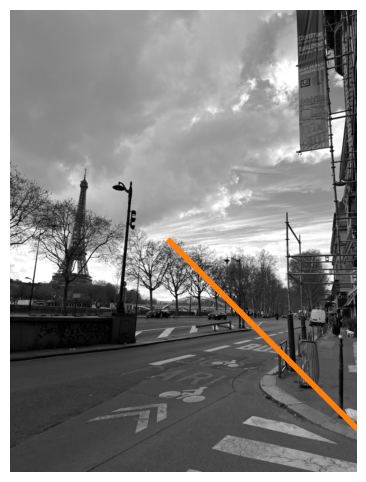

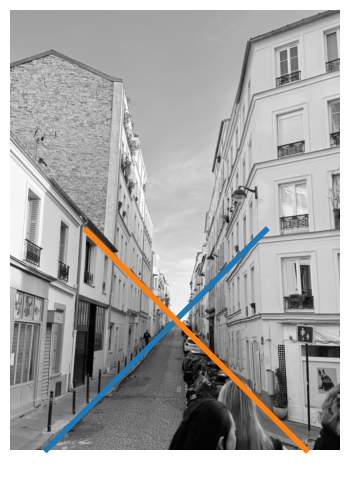

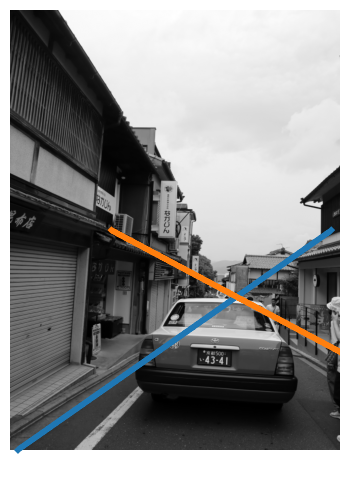

In [14]:
paris_result = apply_hough_lines_angle_filtered(
    paris_img,
    paris_roi,
    min_abs_slope=0.5,
    max_abs_slope=2.5
)

mont_result = apply_hough_lines_angle_filtered(
    mont_img,
    mont_roi,
    min_abs_slope=0.5,
    max_abs_slope=2.5
)

kyoto_result = apply_hough_lines_angle_filtered(
    kyoto_img,
    kyoto_roi,
    min_abs_slope=0.5,
    max_abs_slope=2.5
)

# Try Binary Dilation

In [15]:
def dilate_binary(img, radius=1, iterations=1):
    """
    Simple binary dilation using only NumPy.
    img: binary image, e.g. roi
    radius: neighborhood radius. radius=1 means 3x3 window.
    iterations: number of repeated dilations.
    """
    out = img.astype(bool)

    for _ in range(iterations):
        padded = np.pad(out, radius, mode="constant", constant_values=False)
        dilated = np.zeros_like(out, dtype=bool)

        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                dilated |= padded[
                    radius + dy : radius + dy + out.shape[0],
                    radius + dx : radius + dx + out.shape[1]
                ]

        out = dilated

    return out

In [17]:
paris_roi_dilated = dilate_binary(paris_roi, radius=1, iterations=1)
mont_roi_dilated = dilate_binary(mont_roi, radius=1, iterations=1)
kyoto_roi_dilated = dilate_binary(kyoto_roi, radius=1, iterations=1)

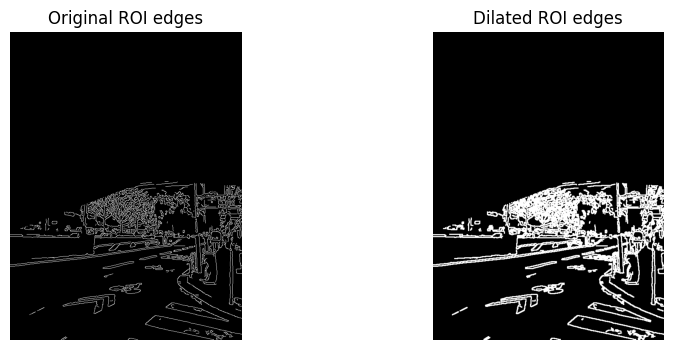

In [18]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(paris_roi, cmap="gray")
plt.title("Original ROI edges")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(paris_roi_dilated, cmap="gray")
plt.title("Dilated ROI edges")
plt.axis("off")

plt.show()

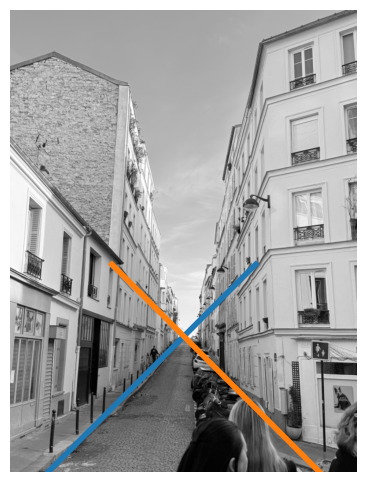

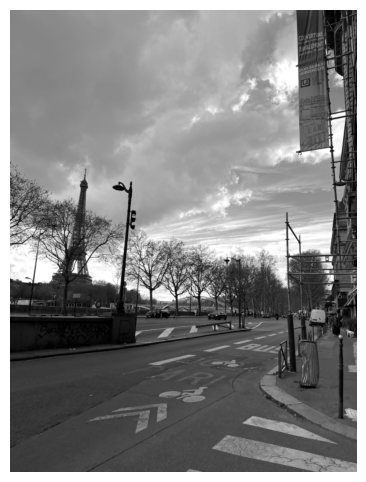

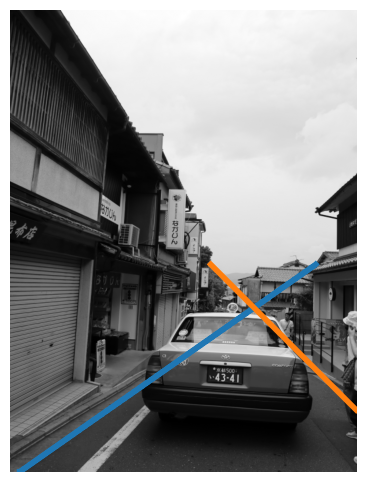

In [21]:
mont_acc_di, mont_rhos_di, mont_thetas_di, mont_left_di, mont_right_di = apply_hough_lines(
    mont_img, mont_roi_dilated
)

paris_acc_di, paris_rhos_di, paris_thetas_di, paris_left_di, paris_right_di = apply_hough_lines(
    paris_img, paris_roi_dilated
)

kyoto_acc_di, kyoto_rhos_di, kyoto_thetas_di, kyoto_left_di, kyoto_right_di = apply_hough_lines(
    kyoto_img, kyoto_roi_dilated
)

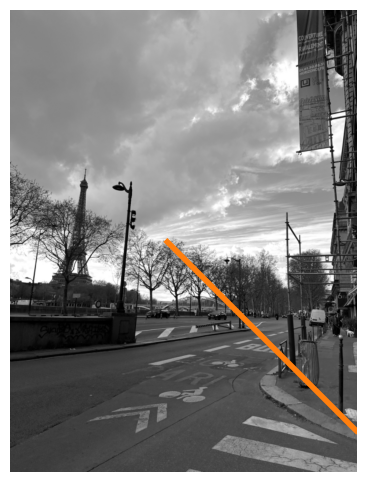

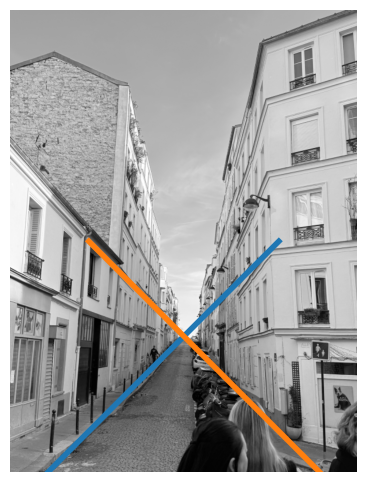

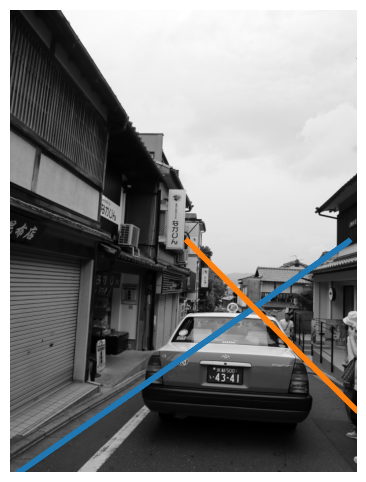

In [22]:
paris_result_di = apply_hough_lines_angle_filtered(
    paris_img,
    paris_roi_dilated,
    min_abs_slope=0.5,
    max_abs_slope=2.5
)

mont_result_di = apply_hough_lines_angle_filtered(
    mont_img,
    mont_roi_dilated,
    min_abs_slope=0.5,
    max_abs_slope=2.5
)

kyoto_result_di = apply_hough_lines_angle_filtered(
    kyoto_img,
    kyoto_roi_dilated,
    min_abs_slope=0.5,
    max_abs_slope=2.5
)

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_

In this extension, I chose images exclusively from urban environments (Paris, Montmartre (also Paris), and Kyoto) to evaluate how the Hough line transform performs outside the highway setting used in Part 1.

From the original Hough transform, the algorithm successfully detects two prominent lines that intersect near the vanishing point in the Montmartre image. However, in the Paris and the Kyoto image, the algorithm identifies only a single line corresponding to the left side of the road. The right boundary is not detected in both cases, likely because they are less visually distinct and partially fragmented. Since the Hough transform relies on strong, continuous edges to accumulate votes, weaker or noisier structures may fail to emerge as dominant peaks.

To improve the quality of detected lines, I introduced angle (slope) filtering. The idea is to restrict Hough candidates to a plausible range of slopes corresponding to perspective road boundaries, while removing near-horizontal lines (e.g., road markings, shadows), and
near-vertical lines (e.g., building edges). This successfully detected both edges in the Kyoto image, but now only identified the right edge (instead of the left) in the Paris image - likely because the left edge was too flat and was therefore eliminated by the slope filter. Nevertheless, from the Kyoto image, we see that angle filtering helps to generate a tighter range of candidates that can make the true lane edge more eminent in the algorithm.

Finally, I tried out morphological dilation treatment to the edge maps before running Hough. The motivation is that Hough voting is stronger when edges are continuous; in real images, edges are often fragmented due to noise or weak gradients. Dilation thickens and connects nearby edge pixels, allowing them to contribute more consistently to the accumulator. This approach improved results for Kyoto, where the relevant road edges were already present but slightly fragmented, but degraded performance on Paris, where there were many non-road edges (e.g., building outlines, textures, shadows), and dilation amplifies all of them indiscriminately.